SCARlink requires scRNA-seq normalized relative counts in [anndata](https://anndata.readthedocs.io/en/stable/) object and the corresponding multiomic scATAC-seq with non-binarized tile matrix in a separate [anndata](https://anndata.readthedocs.io/en/stable/) object. The cell names should be in the same format in both the objects. The scATAC-seq object needs to contain the TileMatrix with tiles of fixed tile width (example: 500bp). This notebook demonstrates how the scRNA-seq and scATAC-seq objects need to be processed in order to run SCARlink. Here we use previously processed PBMC multiomic data from 10x Genomics. The scRNA-seq data set is processed using [scanpy](https://scanpy.readthedocs.io/en/stable/index.html). We generate the scATAC-seq tile matrix using [SnapATAC2](https://kzhang.org/SnapATAC2/). Any other tool that can generate a tile matrix from fragments.tsv file can also be used.

In [1]:
import snapatac2 as snap
import scanpy as sc
import numpy as np
import snapatac2._snapatac2 as internal
import os

Download example PBMC multi-ome scRNA-seq object and fragment file for scATAC-seq.

Download `pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz` and `pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz.tbi` from https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-10-k-1-standard-1-0-0 and save in `pbmc_test_input` directory

In [2]:
os.system("wget https://zenodo.org/records/15716123/files/pbmc_test_input.zip -O ./pbmc_test_input.zip; unzip ./pbmc_test_input.zip")

--2025-06-22 12:03:35--  https://zenodo.org/records/15716123/files/pbmc_test_input.zip
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 175631816 (167M) [application/octet-stream]
Saving to: ‘./pbmc_test_input.zip’

     0K .......... .......... .......... .......... ..........  0%  285K 10m2s
    50K .......... .......... .......... .......... ..........  0% 27.2M 5m4s
   100K .......... .......... .......... .......... ..........  0%  579K 5m1s
   150K .......... .......... .......... .......... ..........  0% 33.1M 3m47s
   200K .......... .......... .......... .......... ..........  0%  596K 3m59s
   250K .......... .......... .......... .......... ..........  0% 23.6M 3m20s
   300K .......... .......... .......... .......... ..........  0% 25.7M 2m53s
   350K .......... .......... .......... .......... ..........  0% 25

Archive:  ./pbmc_test_input.zip
   creating: pbmc_test_input/
  inflating: pbmc_test_input/cell_info_new_ann.txt  
  inflating: pbmc_test_input/pbmc.h5ad  
   creating: pbmc_test_input/pbmc_scatac_test/
  inflating: pbmc_test_input/pbmc_scrna_test.rds  


0

In [2]:
scrna_file = './pbmc_test_input/pbmc.h5ad'
scatac_file = './pbmc_test_input/pbmc_scatac.h5ad' # this will be generated in the notebook
fragment_file = './pbmc_test_input/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz' # downloaded from 10x genomics website

# blacklist file downloaded from https://github.com/Boyle-Lab/Blacklist/blob/master/lists/hg38-blacklist.v2.bed.gz
blacklist_file = './hg38-blacklist.v2.bed.gz'

## Generate tile matrix

In [3]:
scatac_object = snap.pp.import_fragments(fragment_file, 
                                chrom_sizes=snap.genome.hg38, sorted_by_barcode=False)

In [4]:
# Add tile matrix
# We're using tile size of 500
tile_size = 500
snap.pp.add_tile_matrix(scatac_object, bin_size=tile_size)

In [5]:
# Extract blacklisted regions -- the tiles overlapping the blacklisted regions will be set to 0
blacklist_tiles = np.array(internal.intersect_bed(scatac_object.var_names, blacklist_file))
scatac_object.var['blacklist_tiles'] = blacklist_tiles

In [8]:
# format of tile names must be chr:start-end
scatac_object.var_names[:10]

Index(['chr1:0-500', 'chr1:500-1000', 'chr1:1000-1500', 'chr1:1500-2000',
       'chr1:2000-2500', 'chr1:2500-3000', 'chr1:3000-3500', 'chr1:3500-4000',
       'chr1:4000-4500', 'chr1:4500-5000'],
      dtype='object')

## Read scRNA-seq

In [17]:
scrna_object = sc.read_h5ad(scrna_file)

In [9]:
# layer 'counts' must contain the raw counts
# 'highly_variable' must contain the highly variable genes
scrna_object

AnnData object with n_obs × n_vars = 9863 × 26346
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Clusters', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [10]:
scrna_object.var_names[scrna_object.var['highly_variable']]

Index(['LINC01342', 'TTC34', 'CHD5', 'CA6', 'NMNAT1', 'DRAXIN', 'DHRS3',
       'KAZN', 'AL031283.2', 'PADI4',
       ...
       'FMR1-AS1', 'AFF2', 'F8', 'RPS4Y1', 'LINC00278', 'PRKY', 'USP9Y',
       'DDX3Y', 'UTY', 'AC004556.3'],
      dtype='object', length=2000)

In [11]:
scrna_object.layers['counts'].shape

(9863, 26346)

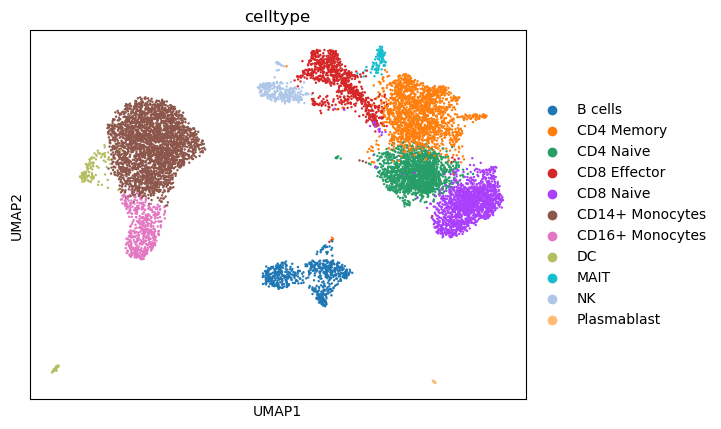

In [12]:
# Plot to check the cell type clusters
sc.pl.umap(scrna_object, color="celltype")

## Check if cell names are in the same format in both scrna.object and scatac.object. If not, update the names to be in the same format.

In [13]:
## cell names in scrna_object
scrna_object.obs_names[:10]

Index(['pbmc#AAACAGCCAAGGAATC-1', 'pbmc#AAACAGCCAATCCCTT-1',
       'pbmc#AAACAGCCAATGCGCT-1', 'pbmc#AAACAGCCACACTAAT-1',
       'pbmc#AAACAGCCACCAACCG-1', 'pbmc#AAACAGCCAGGATAAC-1',
       'pbmc#AAACAGCCAGTAGGTG-1', 'pbmc#AAACAGCCAGTTTACG-1',
       'pbmc#AAACAGCCATCCAGGT-1', 'pbmc#AAACATGCAAGGTCCT-1'],
      dtype='object')

In [14]:
## cell names in scatac_object
scatac_object.obs_names[:10]

Index(['AAACAGCCAAGGAATC-1', 'AAACAGCCAATCCCTT-1', 'AAACAGCCAATGCGCT-1',
       'AAACAGCCACACTAAT-1', 'AAACAGCCACCAACCG-1', 'AAACAGCCAGGATAAC-1',
       'AAACAGCCAGTAGGAT-1', 'AAACAGCCAGTAGGTG-1', 'AAACAGCCAGTTTACG-1',
       'AAACAGCCATCCAGGT-1'],
      dtype='object')

## Update cell names in scatac_object to match the cell names in scrna_object

In [18]:
scatac_object.obs_names = 'pbmc#' + scatac_object.obs_names

In [19]:
## cell names in scatac_object
scatac_object.obs_names[:10]

Index(['pbmc#AAACAGCCAAGGAATC-1', 'pbmc#AAACAGCCAATCCCTT-1',
       'pbmc#AAACAGCCAATGCGCT-1', 'pbmc#AAACAGCCACACTAAT-1',
       'pbmc#AAACAGCCACCAACCG-1', 'pbmc#AAACAGCCAGGATAAC-1',
       'pbmc#AAACAGCCAGTAGGAT-1', 'pbmc#AAACAGCCAGTAGGTG-1',
       'pbmc#AAACAGCCAGTTTACG-1', 'pbmc#AAACAGCCATCCAGGT-1'],
      dtype='object')

## Check common cells in both scRNA-seq and scATAC-seq

In [17]:
scatac_object[scatac_object.obs_names.isin(scrna_object.obs_names)]

View of AnnData object with n_obs × n_vars = 9863 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'blacklist_tiles'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

## Save scATAC-seq tile matrix

In [18]:
scatac_object.write_h5ad(scatac_file)

# Running SCARlink

Please refer to [tutorial notebook](https://github.com/snehamitra/SCARlink/blob/main/notebooks/tutorial.ipynb) for more details. 

In [2]:
## SCARlink preprocessing -- THIS STEP IS SLOW. Faster version is available with Seurat and ArchR objects as input
# !scarlink_processing --scrna pbmc_test_input/pbmc.h5ad --scatac pbmc_test_input/pbmc_scatac.h5ad -o pbmc_test \
#                                -g hg38 

In [3]:
## Running SCARlink
# !scarlink -o pbmc_test -g hg38 

In [ ]:
## Predict enhancers
# !scarlink_tiles 